In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("WineQT.csv")
df.sample(4)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
442,8.8,0.600,0.29,2.2,0.098,5.0,15.0,0.99880,3.36,0.49,9.1,5,626
891,6.3,1.020,0.00,2.0,0.083,17.0,24.0,0.99437,3.59,0.55,11.2,4,1261
90,8.0,0.745,0.56,2.0,0.118,30.0,134.0,0.99680,3.24,0.66,9.4,5,130
452,9.6,0.880,0.28,2.4,0.086,30.0,147.0,0.99790,3.24,0.53,9.4,5,636


In [3]:
df= df.drop("Id", axis=1)
x = df.drop("quality", axis=1)
y = df["quality"]

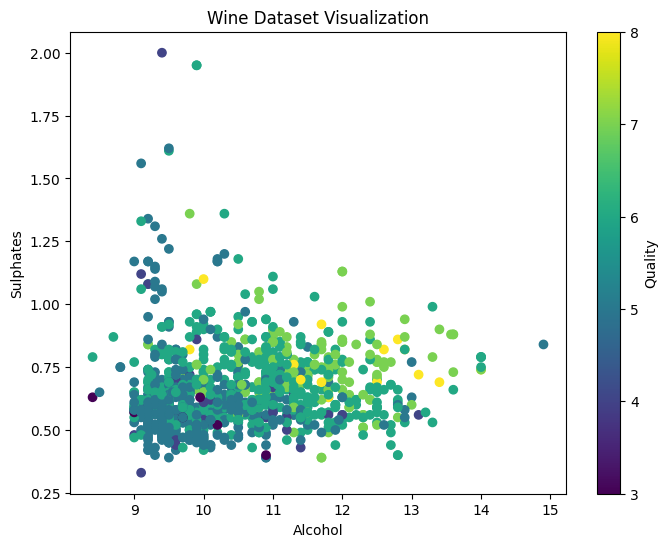

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['alcohol'],
    df['sulphates'],
    c=df['quality']
)

plt.xlabel("Alcohol")
plt.ylabel("Sulphates")
plt.title("Wine Dataset Visualization")

plt.colorbar(label="Quality")

plt.show()

In [5]:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=44)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [7]:
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
knc = KNeighborsClassifier()
knc.fit(x_train, y_train)
knc.score(x_test, y_test)
predict  = knc.predict(x_test)
# knc.predict_proba(x_test)

In [8]:
print("Confusion Matrix")
print(confusion_matrix(y_test, predict))
print("Accuracy Score")
accuracy_score(y_test, predict)

Confusion Matrix
[[ 0  3  1  1  0]
 [ 3 61 21  3  0]
 [ 1 35 57  5  0]
 [ 0  7 16 13  0]
 [ 0  1  1  0  0]]
Accuracy Score


0.5720524017467249

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15,17,19],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
0.6247042574911428


In [10]:
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
knc = KNeighborsClassifier(metric = "manhattan", n_neighbors= 15, weights= 'distance')
knc.fit(x_train, y_train)
knc.score(x_test, y_test)
predict  = knc.predict(x_test)
# knc.predict_proba(x_test)

In [11]:
print("Confusion Matrix")
print(confusion_matrix(y_test, predict))
print("Accuracy Score")
accuracy_score(y_test, predict)

Confusion Matrix
[[ 0  1  3  1  0]
 [ 2 65 20  1  0]
 [ 0 32 61  5  0]
 [ 0  1 11 23  1]
 [ 0  0  1  0  1]]
Accuracy Score


0.6550218340611353

In [13]:
sample = pd.DataFrame([{
    'fixed acidity': 7.1,
    'volatile acidity': 0.60,
    'citric acid': 0.01,
    'residual sugar': 2.3,
    'chlorides': 0.079,
    'free sulfur dioxide': 24.0,
    'total sulfur dioxide': 37.0,
    'density': 0.99514,
    'pH': 3.40,
    'sulphates': 0.61,
    'alcohol': 10.9
}])

sample_scaled = scaler.transform(sample)

prediction = knc.predict(sample_scaled)

print("Predicted Wine Quality:", prediction[0])

Predicted Wine Quality: 6


In [14]:
# Regression

In [16]:
knr = KNeighborsRegressor()

knr.fit(x_train, y_train)

KNeighborsRegressor()

In [17]:
y_pred = knr.predict(x_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
print("MAE")
print(mean_absolute_error(y_test, y_pred))

print("\nMSE")
print(mean_squared_error(y_test, y_pred))

print("\nRMSE")
print(mean_squared_error(y_test, y_pred) ** 0.5)

print("\nR2 Score")
print(r2_score(y_test, y_pred))

MAE
0.5117903930131005

MSE
0.46218340611353714

RMSE
0.6798407211351326

R2 Score
0.22918967052537842


In [ ]:
# using GridSearch

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_reg = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_search_reg.fit(x_train, y_train)

print(grid_search_reg.best_params_)
print(grid_search_reg.best_score_)

{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
0.3888216602770934


In [ ]:
# Using best hyperparameters

In [24]:
knr = KNeighborsRegressor(metric = "manhattan", n_neighbors= 15, weights= 'distance')

knr.fit(x_train, y_train)
y_pred = knr.predict(x_test)

In [25]:
print("MAE")
print(mean_absolute_error(y_test, y_pred))

print("\nMSE")
print(mean_squared_error(y_test, y_pred))

print("\nRMSE")
print(mean_squared_error(y_test, y_pred) ** 0.5)

print("\nR2 Score")
print(r2_score(y_test, y_pred))

MAE
0.3924411236782646

MSE
0.3218303858592646

RMSE
0.5673009658543379

R2 Score
0.4632646207592642


In [27]:
# Custom input

In [26]:
prediction = grid_search_reg.best_estimator_.predict(sample_scaled)

print("Predicted Wine Quality:", prediction[0])

Predicted Wine Quality: 6.0
